# CIDM Lab 2


**Course:** P170M109 Computational Intelligence and Decision Making
**Author:** Rokas Marcinkevi2ius
**Date:** _2025-10-20_

- **Part 1 – Regression using ANN** (reuses Lab 1 dataset)
- **Part 2 – Image Classification** (from scratch + transfer learning)
- **Part 3 – Object Detection & Segmentation** (YOLOv8; segmentation optional)


In [27]:
import sys, platform, numpy as np, pandas as pd, matplotlib, sklearn
print('Python:', sys.version.split()[0])
print('OS:', platform.system(), platform.release())
print('numpy:', np.__version__)
print('pandas:', pd.__version__)
print('sklearn:', sklearn.__version__)
print('matplotlib:', matplotlib.__version__)


Python: 3.13.2
OS: Darwin 25.0.0
numpy: 2.2.6
pandas: 2.3.2
sklearn: 1.7.2
matplotlib: 3.10.6


## Part 1 — Load Lab 1 Dataset

In [28]:
# P1. Data analysis and preprocessing
# 1) Load data (robust file search)

# Robust read with CSV sniffer and fallbacks (handles stray commas/quotes)
import csv
from pandas.errors import ParserError


def read_csv_robust(path: Path) -> pd.DataFrame:
    # 1) Try to sniff delimiter/quote using csv.Sniffer on a small sample
    try:
        with open(path, 'r', encoding='utf-8', errors='replace') as f:
            sample = f.read(131072)
        dialect = csv.Sniffer().sniff(sample, delimiters=",;\t|")
        delim = dialect.delimiter
        qchar = dialect.quotechar if getattr(dialect, 'quotechar', '"') else '"'
    except Exception:
        delim, qchar = None, '"'  # let pandas infer sep when None

    # 2) Try utf-8 first, engine='python' for better malformed line handling
    try:
        return pd.read_csv(
            path,
            sep=delim,  # None => infer
            encoding='utf-8',
            engine='python',
            quotechar=qchar,
            escapechar='\\',
            doublequote=True,
            on_bad_lines='skip',  # skip malformed rows instead of failing
        )
    except UnicodeDecodeError:
        # 3) Fallback encoding (Windows-1252) with same tolerant settings
        return pd.read_csv(
            path,
            sep=delim,
            encoding='cp1252',
            engine='python',
            quotechar=qchar,
            escapechar='\\',
            doublequote=True,
            on_bad_lines='skip',
        )
    except ParserError:
        # 4) Last resort: let pandas infer delimiter and try again
        return pd.read_csv(
            path,
            sep=None,
            encoding='utf-8',
            engine='python',
            quotechar='"',
            escapechar='\\',
            doublequote=True,
            on_bad_lines='skip',
        )


df_raw = read_csv_robust(data_path)
print("Loaded file:", data_path)
print("Raw shape:", df_raw.shape)
try:
    display(df_raw.head(3))
except NameError:
    pass


Loaded file: /Users/rokas/Documents/KTU AI Masters/P170M109-Computational-Intelligence-and-Decision-Making/Lab 2/apartments_for_rent_classified_100K.csv
Raw shape: (99637, 22)


,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668640009,housing/rent/apartment,One BR 507 & 509 Esplanade,"This unit is located at 507 & 509 Esplanade, R...",NaN,1.0,1.0,USD,No,Thumbnail,...,"$2,195",Monthly,542,507 509 Esplanade,Redondo Beach,CA,33.8520,-118.3759,RentLingo,1577360355
1,5668639818,housing/rent/apartment,Three BR 146 Lochview Drive,"This unit is located at 146 Lochview Drive, Ne...",NaN,1.5,3.0,USD,No,Thumbnail,...,"$1,250",Monthly,1500,146 Lochview Dr,Newport News,VA,37.0867,-76.4941,RentLingo,1577360340
2,5668639686,housing/rent/apartment,Three BR 3101 Morningside Drive,This unit is located at 3101 Morningside Drive...,NaN,2.0,3.0,USD,No,Thumbnail,...,"$1,395",Monthly,1650,3101 Morningside Dr,Raleigh,NC,35.8230,-78.6438,RentLingo,1577360332


### Preprocessing
⸻

🧹 1. Preprocessing — Cleaning the Data

Before training, we make sure the dataset is clean, consistent, and realistic.

⸻

💸 2. Convert all prices to monthly rent

Some listings show rent per week, per day, or per year —
we convert them all to monthly rent so everything is in the same unit.

Type	Example	Conversion
weekly	€400 / week	× 52 / 12
daily	€40 / day	× 30
yearly	€12,000 / year	÷ 12
hourly	€1 / hour	× 24 × 30
monthly	€1,000 / month	leave as is

Now all prices are in €/month, so models can compare them properly.

⸻

🧱 3. Remove unrealistic or broken data

We drop entries that make no sense or are likely errors:
	•	Apartments smaller than 120 sq ft or larger than 8000 sq ft
	•	Listings with zero or missing prices

This keeps only realistic, usable data.

⸻

🚫 4. Handle outliers

We cap extremely expensive listings above the 99.5% quantile
to prevent luxury outliers from distorting results.

⸻

🔁 5. Drop duplicates

Some listings appear multiple times (same title, city, and details).
We keep only one copy of each.

⸻

✅ Result:
After preprocessing, the data is clean, realistic, and ready for model training.

In [70]:
import numpy as np
import pandas as pd
import re

# assume you already have df_raw from the CSV load step
listings_source = df_raw
listings = listings_source.copy()

# --- 0) Guards and type coercion ---
required_columns = {"price", "price_type"}
missing = required_columns - set(listings.columns)
if missing:
    raise KeyError(f"Missing required columns: {sorted(missing)}")

# Make numeric where needed; strings like "1,200" -> 1200.0
listings["price"] = (
    pd.to_numeric(listings["price"].astype(str).str.replace(",", ""), errors="coerce")
)

# --- 1) Convert to monthly rent (robust to unit variants) ---
def normalize_unit(unit: str) -> str:
    """Lowercase, strip, remove non-letters to catch 'per week', 'p/w', etc."""
    if unit is None:
        return ""
    u = re.sub(r"[^a-z]", "", str(unit).strip().lower())
    return u

def convert_price_to_monthly(price, price_type: str):
    if pd.isna(price):
        return np.nan
    u = normalize_unit(price_type)
    # Weekly
    if u in {"week", "weekly", "pw"}:
        return price * (52.0 / 12.0)
    # Fortnightly
    if u in {"fortnightly", "biweekly", "perfortnight"}:
        return price * (26.0 / 12.0)
    # Daily
    if u in {"day", "daily"}:
        return price * 30.0
    # Yearly
    if u in {"year", "yearly", "peryear", "pa"}:
        return price / 12.0
    # Hourly
    if u in {"hour", "hourly"}:
        return price * 24.0 * 30.0
    # Monthly (or unknown -> assume monthly)
    if u in {"month", "monthly", "permonth", "pm", "pcm"} or u == "":
        return price
    # Fallback: assume monthly
    return price

listings["monthly_rent"] = [
    convert_price_to_monthly(p, t) for p, t in zip(listings["price"], listings["price_type"])
]

# --- 2) Basic sanity filters ---
# Keep rows with valid/positive monthly rent
listings = listings[listings["monthly_rent"].notna() & (listings["monthly_rent"] > 0)]

# Square feet: keep NaNs (unknown size is okay), but filter unrealistic values if present
if "square_feet" in listings.columns:
    sq_ft = pd.to_numeric(listings["square_feet"], errors="coerce")
    keep_mask = sq_ft.isna() | sq_ft.between(120, 8000)
    listings = listings[keep_mask]

# --- 3) Cap extreme outliers (top 0.5%) to stabilize training ---
upper_bound = listings["monthly_rent"].quantile(0.995)
listings["monthly_rent"] = listings["monthly_rent"].clip(upper=upper_bound)

# --- 4) Drop likely duplicates (if those columns exist) ---
dedupe_keys = [
    c for c in ["title","description","city","region","state","price","square_feet","beds","baths"]
    if c in listings.columns
]
if dedupe_keys:
    listings = listings.drop_duplicates(subset=dedupe_keys)

print("Cleaned shape:", listings.shape)
listings[["price", "price_type", "monthly_rent"]].head(5)


Cleaned shape: (98927, 23)


,price,price_type,monthly_rent
0,2195.0,Monthly,2195.0
1,1250.0,Monthly,1250.0
2,1395.0,Monthly,1395.0
3,1600.0,Monthly,1600.0
4,975.0,Monthly,975.0


### Features & Target
	1.	Pick inputs you’ll actually use
We separate numeric columns (sizes, counts, coordinates, flags) from categorical ones (location labels).
Only columns that exist in listings are kept—no KeyErrors.
	2.	Assemble the modeling table
selected_columns = all chosen inputs + the target monthly_rent.
We create modeling_data from those columns and drop rows without a target (can’t train without labels).
	3.	Create clean inputs/labels
	•	feature_table = everything except the target (what the model sees)
	•	target_rent = the thing we want to predict (as float)
	4.	Sanity prints
We print shapes and cardinalities (how many unique states/cities/regions).
This helps you estimate one lot size and spot weird datasets early.

⸻


In [75]:
# --- Feature and Target Selection (matches apartments_for_rent_classified_10K.csv) ---

# Ensure flags are numeric (0/1) if they came as "yes"/"no"
for flag in ["fee", "has_photo"]:
    if flag in listings.columns and listings[flag].dtype not in ("int64", "float64"):
        listings[flag] = (
            listings[flag]
            .astype(str).str.lower()
            .map({"yes": 1, "true": 1, "1": 1, "no": 0, "false": 0, "0": 0})
            .fillna(0).astype(int)
        )

# Derive optional features from existing columns (present in your dataset)
if "pets_allowed" in listings.columns and "pet_cat_allowed" not in listings.columns:
    lower = listings["pets_allowed"].fillna("").astype(str).str.lower()
    listings["pet_cat_allowed"] = lower.str.contains("cat").astype(int)
    listings["pet_dog_allowed"] = lower.str.contains("dog").astype(int)

if "amenities" in listings.columns and "amenity_count" not in listings.columns:
    listings["amenity_count"] = (
        listings["amenities"].fillna("").astype(str)
        .apply(lambda s: 0 if not s.strip() else len([a for a in s.split(",") if a.strip()]))
        .astype(int)
    )

# Choose columns that actually exist in THIS dataset
numeric_columns = [
    c for c in [
        "square_feet", "bedrooms", "bathrooms",
        "latitude", "longitude",
        "fee", "has_photo",
        "amenity_count", "pet_cat_allowed", "pet_dog_allowed"
    ] if c in listings.columns
]

# Note: the dataset uses 'cityname' (not 'city') and has no 'region'
categorical_columns = [c for c in ["state", "cityname", "source", "category"] if c in listings.columns]

print("Numeric columns:", numeric_columns)
print("Categorical columns:", categorical_columns)

# Build modeling table
selected_columns = numeric_columns + categorical_columns + ["monthly_rent"]
if "monthly_rent" not in listings.columns:
    raise KeyError("Expected 'monthly_rent' column. Run preprocessing/conversion first.")

modeling_data = listings[selected_columns].dropna(subset=["monthly_rent"]).copy()

# Split inputs/target
feature_table = modeling_data.drop(columns=["monthly_rent"])
target_rent = modeling_data["monthly_rent"].astype(float)

print("Modeling data shape:", modeling_data.shape)

# Cardinality checks for your actual columns
if "state" in listings.columns:
    print("Unique states:", listings["state"].nunique())
if "cityname" in listings.columns:
    print("Unique citynames:", listings["cityname"].nunique())
if "source" in listings.columns:
    print("Unique sources:", listings["source"].nunique())

Numeric columns: ['square_feet', 'bedrooms', 'bathrooms', 'latitude', 'longitude', 'fee', 'has_photo', 'amenity_count', 'pet_cat_allowed', 'pet_dog_allowed']
Categorical columns: ['state', 'cityname', 'source', 'category']
Modeling data shape: (98927, 15)
Unique states: 51
Unique citynames: 2981
Unique sources: 25


### Split Train/Val/Test
What’s happening when we split the data?
	•	We cut the dataset into three boxes:
	•	Training (70%) – the box the model learns from.
	•	Validation (15%) – the box we use to try settings (like how many neighbors, tree depth) without cheating.
	•	Test (15%) – the secret box we open only once at the end to see how good the model really is.
	•	We split in two steps:

	1.	First make a big learning box (Train) and a holding box (Temp).
	2.	Then split Temp into Validation and Test equally.
This keeps the Test box sealed until the very end.
	•	We use a fixed random seed (42) so you and I get the same split every time.
	•	Prices can vary a lot, so we put them into buckets (cheap → pricey) before splitting; this helps each box have a similar mix of prices.

In [77]:
# --- Train / Validation / Test Split (70 / 15 / 15) ---
from sklearn.model_selection import train_test_split
import pandas as pd

RANDOM_SEED = 42  # reproducible splits

def make_stratify_bins(y: pd.Series, n_bins: int = 10):
    """
    For regression: approximate stratification by binning target into quantiles.
    Returns a categorical series for stratify=... or None if not possible.
    """
    y = pd.Series(y).astype(float)
    non_na = y.dropna()
    if non_na.nunique() < max(3, n_bins):  # not enough unique values
        return None
    try:
        return pd.qcut(y, q=n_bins, duplicates="drop")
    except Exception:
        return None

# 0) Optional: build bins so each split has a similar rent distribution
strata_all = make_stratify_bins(target_rent, n_bins=10)

# 1) Train (70%) vs Temp (30%)
features_train, features_temp, target_train, target_temp = train_test_split(
    feature_table,
    target_rent,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=strata_all if strata_all is not None else None,
)

# 2) Validation (15%) vs Test (15%) from Temp (50/50 of the 30%)
strata_temp = make_stratify_bins(target_temp, n_bins=10)
features_validation, features_test, target_validation, target_test = train_test_split(
    features_temp,
    target_temp,
    test_size=0.50,   # 50% of 30% = 15% overall
    random_state=RANDOM_SEED,
    stratify=strata_temp if strata_temp is not None else None,
)

# Optional: reset indices for cleanliness
for s in (features_train, features_validation, features_test,
          target_train, target_validation, target_test):
    s.index = range(len(s))

print(
    "Sizes (rows):",
    len(features_train), len(features_validation), len(features_test),
    " -> ratios:",
    round(len(features_train) / len(feature_table), 3),
    round(len(features_validation) / len(feature_table), 3),
    round(len(features_test) / len(feature_table), 3),
)


Sizes (rows): 69248 14839 14840  -> ratios: 0.7 0.15 0.15


### Pipelines & Metrics

We build pipelines that:

	1.	Fill missing values (median for numbers, most-frequent for text),
	2.	Encode categories into numbers (One-Hot),
	3.	Optionally scale numeric features (needed for distance models like KNN; not needed for trees/forests).

We also define common metrics:

	•	MAE (average miss in €),
	•	MAPE (average % miss; ignores zeros to avoid division problems),
	•	RMSE (MAE but big errors hurt more),
	•	R² (how much of the price variation we explain).


In [80]:
# --- Pipelines & Metrics ---
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# Expecting these from previous cells:
# numeric_columns, categorical_columns, feature_table, target_rent

# ---------- Metrics ----------
def mape_masked(y_true, y_pred, eps=1e-8):
    """Mean Absolute Percentage Error, skipping tiny/zero truths."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.abs(y_true) > eps
    if not np.any(mask):
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100.0

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def evaluate_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MAPE_%": mape_masked(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

# ---------- Encoders / Imputers ----------
# OneHotEncoder compat: newer sklearn uses sparse_output; older uses sparse
try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_imputer = SimpleImputer(strategy="median")
categorical_imputer = SimpleImputer(strategy="most_frequent")

# Helper to build preprocessors for two families of models
def build_preprocessor(scale_numeric: bool):
    numeric_steps = [("imputer", numeric_imputer)]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))
    numeric_pipe = Pipeline(numeric_steps)

    categorical_pipe = Pipeline([
        ("imputer", categorical_imputer),
        ("onehot", onehot),
    ])

    transformers = []
    if numeric_columns:
        transformers.append(("num", numeric_pipe, numeric_columns))
    if categorical_columns:
        transformers.append(("cat", categorical_pipe, categorical_columns))

    if not transformers:
        raise ValueError("No numeric or categorical columns available. Check your feature lists.")

    return ColumnTransformer(transformers=transformers, remainder="drop")

# Use this one for KNN or any distance-based model
preprocess_scaled = build_preprocessor(scale_numeric=True)

# Use this one for Trees/RandomForest/GBM (they don't need scaling)
preprocess_tree = build_preprocessor(scale_numeric=False)


## Baselines — KNN / DecisionTree / RandomForest

Imagine you’re buying a house, and you want to guess how much rent it costs.
Let’s say you already know the rent for a bunch of other houses.

Now — three friends try to help you guess:

⸻

🧍‍♂️1. KNN — “the neighbor guesser”

KNN means K-Nearest Neighbors.

👧 It looks at houses closest to the one you’re checking (the “neighbors”).
If 3 nearby houses rent for 900, 1000, and 1100 → it says, “Yours is probably around 1000!”

	•	It cares about distance (how similar houses are — size, rooms, location).
	•	That’s why we scale features — so “square_feet” doesn’t overshadow “bedrooms.”
	•	Small k (few neighbors) → very sensitive, noisy.
	•	Big k → too smooth, misses small details.

🧠 Think: “Ask your few closest neighbors what they pay.”

⸻

🌳2. Decision Tree — “the question asker”

The tree asks yes/no questions to split the data.

🌲 “Is it bigger than 100m²?”
→ If yes: “Does it have 2 bathrooms?”
→ If no: “Is it in the city center?”

At the end of each branch (leaf), the tree says:
“Most houses like this cost around X.”
	•	Deep tree = lots of questions → may overfit (memorize training data).
	•	Shallow tree = few questions → may underfit (too simple).

🧠 Think: “Play 20 questions to guess the rent.”

⸻

🌲🌲🌲3. Random Forest — “the team of trees”

A forest is just many decision trees working together.

🌳🌳🌳 Each tree asks slightly different questions.
Then they all vote or average their answers.

This makes it:
	•	More stable (one noisy tree won’t ruin it).
	•	More accurate (averaging cancels out mistakes).
	•	Harder to overfit than one big tree.

🧠 Think: “Ask 100 smart friends instead of one.”

📊 Model Score Meanings (a.k.a. “How good was our guess?”)

When we teach a computer to guess prices, we need to check how close its guesses are.
These numbers tell us that.

⸻

💸 MAE — Mean Absolute Error

➡️ “How far off are we, on average?”

If real rent is €1000 and the model said €1100 → that’s €100 off.
MAE is just the average of all those “how off” numbers.

🧠 Smaller MAE = better guesses.

⸻

📉 MAPE — Mean Absolute Percentage Error

➡️ “How wrong were we, as a percent?”

If the true price is €1000 and we guessed €1100 → that’s 10% error.
MAPE tells us the average percent mistake.

⚠️ But if real prices are tiny, percentages go crazy.

⸻

📈 RMSE — Root Mean Square Error

➡️ “Like MAE, but big mistakes hurt extra.”

If we guessed way too high or way too low, RMSE will jump more.

🧠 Good when you want to punish big misses.

⸻

🧩 R² — R-squared

➡️ “How much of the story did we explain?”

R² = 1 → perfect predictions 🎯
R² = 0 → as dumb as just saying “everyone pays the average” 😅

🧠 Higher R² = smarter model.

Metric
What it means
Goal
MAE
Average how much we’re off (€)
↓ Lower = better
MAPE
Average % we’re off
↓ Lower = better
RMSE
Like MAE, but punishes big mistakes
↓ Lower = better
R²
How much of price differences we explained
↑ Higher = better


MAE and RMSE tell you “how far” your guesses are;
MAPE says “how wrong in %”;
R² says “how smart your model really is.”


In [81]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

# Expected from earlier cells:
#   features_train, features_validation, features_test
#   target_train,   target_validation,   target_test
#   preprocess_scaled, preprocess_tree
#   evaluate_metrics(y_true, y_pred)  # returns dict with MAE, MAPE_%, RMSE, R2

validation_results = {}

def fit_and_eval_on_validation(name: str, model, preprocessor):
    pipeline = Pipeline([("prep", preprocessor), ("model", model)])
    pipeline.fit(features_train, target_train)
    preds_val = pipeline.predict(features_validation)
    metrics = evaluate_metrics(target_validation, preds_val)
    validation_results[name] = metrics
    return pipeline, metrics

# --- Model selection on VALIDATION ---
_, knn_val  = fit_and_eval_on_validation("KNN(k=5)", KNeighborsRegressor(n_neighbors=5), preprocess_scaled)
_, dt_val   = fit_and_eval_on_validation("DecisionTree", DecisionTreeRegressor(random_state=42), preprocess_tree)
_, rf_val   = fit_and_eval_on_validation("RandomForest(n=200,leaf=1)", RandomForestRegressor(
    n_estimators=200, min_samples_leaf=1, random_state=42, n_jobs=-1
), preprocess_tree)

print("Validation metrics:")
display(pd.DataFrame(validation_results).T)

# --- Final TEST: retrain on Train+Validation, then test once (honest score) ---
final_test_results = {}

def retrain_and_test(name: str, model, preprocessor):
    pipeline = Pipeline([("prep", preprocessor), ("model", model)])
    # retrain on Train + Validation for more signal
    features_trv = pd.concat([features_train, features_validation], axis=0)
    target_trv   = pd.concat([target_train,   target_validation],   axis=0)
    pipeline.fit(features_trv, target_trv)
    preds_test = pipeline.predict(features_test)
    final_test_results[name] = evaluate_metrics(target_test, preds_test)

retrain_and_test("KNN(k=5)", KNeighborsRegressor(n_neighbors=5), preprocess_scaled)
retrain_and_test("DecisionTree", DecisionTreeRegressor(random_state=42), preprocess_tree)
retrain_and_test("RandomForest(n=200,leaf=1)", RandomForestRegressor(
    n_estimators=200, min_samples_leaf=1, random_state=42, n_jobs=-1
), preprocess_tree)

print("Final TEST metrics:")
display(pd.DataFrame(final_test_results).T)


Validation metrics:


,MAE,MAPE_%,RMSE,R2
KNN(k=5),246.178077,17.282100,383.596932,0.718348
DecisionTree,194.787888,13.260621,356.644592,0.756537
"RandomForest(n=200,leaf=1)",159.964283,11.015842,275.265560,0.854967


Final TEST metrics:


,MAE,MAPE_%,RMSE,R2
KNN(k=5),236.413846,16.582094,373.432128,0.732585
DecisionTree,186.169681,12.464511,339.932054,0.778412
"RandomForest(n=200,leaf=1)",152.718883,10.425521,263.042525,0.867318


## 🧠 ANN (MLPRegressor) — Grid Search + Learning Curve

### What this ANN Grid Search actually does

- We’re training a **neural network (`MLPRegressor`)** — a model that learns patterns by combining many simple “neurons” in layers.
  It predicts the apartment’s **monthly rent** from all your features.

- The **grid search (`GridSearchCV`)** part tries different settings:
  - how many layers and neurons (`hidden_layer_sizes`)
  - how strong regularization is (`alpha`)
  - how fast it learns (`learning_rate_init`)
  - how big each training step is (`batch_size`)
  - which activation function to use (`relu` or `tanh`)

- For each setting, it performs **3-fold cross-validation**:
  1. Split the training data into 3 parts.
  2. Train on 2 parts, validate on 1.
  3. Rotate until every part has been validated once.
  4. Average the 3 results → that’s the **mean CV score**.

- Because scikit-learn expects “higher is better”, it stores the **negative MAE**.
  → So a score of `-339` actually means an **MAE of 339** (lower is better in reality).

- At the end:
  - **`best_params_`** shows the parameter combination with the smallest MAE.
  - **`best_score_`** (after flipping the sign) is the average MAE across folds.
  - The result table lists the top configurations and their scores.

---

### 🧩 In short
We let the computer test dozens of different neural-network shapes and learning speeds,
measured how far off each one was when guessing rent prices,
and kept the model with the **smallest average mistake (~€339 per month)**.

In [34]:
# --- ANN (MLPRegressor) — Grid Search + Validation evaluation ---

from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np

# Expected from earlier cells:
#   features_train, features_validation, features_test
#   target_train,   target_validation,   target_test
#   preprocess_scaled            # includes median impute + OneHot + StandardScaler for numerics
#   evaluate_metrics(y_true, y_pred)  # returns dict with MAE, MAPE_%, RMSE, R2

ann_pipeline = Pipeline([
    ("prep", preprocess_scaled),
    ("model", MLPRegressor(
        random_state=42,
        early_stopping=True,       # uses an internal validation split on each CV fold
        max_iter=1000,
        n_iter_no_change=30,
        validation_fraction=0.15   # fraction of the training-fold for early stopping
    ))
])

param_grid = {
    "model__hidden_layer_sizes": [(128, 64, 32), (128, 64), (64, 32)],
    "model__alpha": [1e-4, 1e-3],
    "model__learning_rate_init": [1e-3, 3e-4],
    "model__activation": ["relu", "tanh"],
    "model__batch_size": [64, 128],
}

# Grid search on the TRAIN split only
gcv = GridSearchCV(
    ann_pipeline,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",  # scikit returns negative MAE so "higher is better"
    cv=3,
    n_jobs=-1,
    verbose=1,
    refit=True,  # refit best model on the full TRAIN split automatically
)

gcv.fit(features_train, target_train)

best_params = gcv.best_params_
best_cv_mae = -gcv.best_score_  # make it positive

print("Best params:", best_params)
print("Best CV MAE:", best_cv_mae)

# Show top 10 CV configs with positive MAE for readability
cv_table = pd.DataFrame(gcv.cv_results_).sort_values("rank_test_score").head(10)
cv_table = cv_table.assign(mean_MAE=lambda d: -d["mean_test_score"]).loc[:, [
    "rank_test_score", "mean_MAE",
    "param_model__hidden_layer_sizes",
    "param_model__alpha",
    "param_model__learning_rate_init",
    "param_model__activation",
    "param_model__batch_size",
]]
display(cv_table)

# Validate the chosen model on our held-out VALIDATION split (fair model selection)
best_model = gcv.best_estimator_                   # already refit on TRAIN
val_preds = best_model.predict(features_validation)
val_metrics = evaluate_metrics(target_validation, val_preds)
print("Validation metrics (best ANN):", val_metrics)

# (Later) Final TEST: retrain on TRAIN+VALIDATION, then test once
features_trv = pd.concat([features_train, features_validation], axis=0)
target_trv   = pd.concat([target_train,   target_validation],   axis=0)

final_ann = Pipeline([
    ("prep", preprocess_scaled),
    ("model", MLPRegressor(
        random_state=42,
        early_stopping=True,
        max_iter=1000,
        n_iter_no_change=30,
        validation_fraction=0.15,
        hidden_layer_sizes=best_params["model__hidden_layer_sizes"],
        alpha=best_params["model__alpha"],
        learning_rate_init=best_params["model__learning_rate_init"],
        activation=best_params["model__activation"],
        batch_size=best_params["model__batch_size"],
    ))
])
final_ann.fit(features_trv, target_trv)
test_preds = final_ann.predict(features_test)
test_metrics = evaluate_metrics(target_test, test_preds)
print("Final TEST metrics (ANN):", test_metrics)

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best params: {'model__activation': 'relu', 'model__alpha': 0.0001, 'model__batch_size': 64, 'model__hidden_layer_sizes': (128, 64), 'model__learning_rate_init': 0.0003}
Best CV MAE: 339.6508126150896


,rank_test_score,mean_test_score,param_model__hidden_layer_sizes,param_model__alpha,param_model__learning_rate_init,param_model__activation,param_model__batch_size,mean_MAE
3,1,-339.650813,"(128, 64)",0.0001,0.0003,relu,64,339.650813
2,2,-339.719346,"(128, 64)",0.0001,0.0010,relu,64,339.719346
16,3,-340.104273,"(64, 32)",0.0010,0.0010,relu,64,340.104273
9,4,-340.183012,"(128, 64)",0.0001,0.0003,relu,128,340.183012
44,5,-340.186053,"(128, 64)",0.0010,0.0010,tanh,128,340.186053
21,6,-340.337503,"(128, 64)",0.0010,0.0003,relu,128,340.337503
8,7,-340.352175,"(128, 64)",0.0001,0.0010,relu,128,340.352175
26,8,-340.375072,"(128, 64)",0.0001,0.0010,tanh,64,340.375072
38,9,-340.431561,"(128, 64)",0.0010,0.0010,tanh,64,340.431561
4,10,-340.518951,"(64, 32)",0.0001,0.0010,relu,64,340.518951


## 🧠 ANN (MLPRegressor) — Final Test Evaluation + Diagnostic Plots

**What we do here**
- **Retrain** the best ANN on **Train + Validation** (more data, fixed hyperparameters).
- **Evaluate once** on the **Test** split (honest final score).
- Plot quick diagnostics:
  - **Predicted vs Actual** — should hug the diagonal if predictions are good.
  - **Residual Histogram** — residuals (pred − actual) should be centered near 0.
  - **Residual vs Predicted** — checks for heteroscedasticity or pattern in errors.

**Why retrain on Train+Val?**
After hyperparameters are chosen via CV/validation, we give the model all non-test data to learn as much as possible before the single final Test check.

**Notes**
- Use the **scaled** preprocessing for ANN.
- Do **not** touch the Test split until this step.

Final TEST metrics (ANN): {'MAE': 210.44470869713643, 'MAPE%': 14.60366066638891, 'RMSE': 322.73599962675087, 'R2': 0.800263915708072}


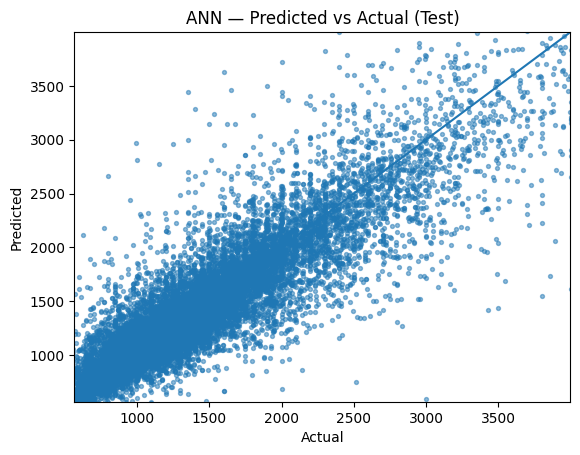

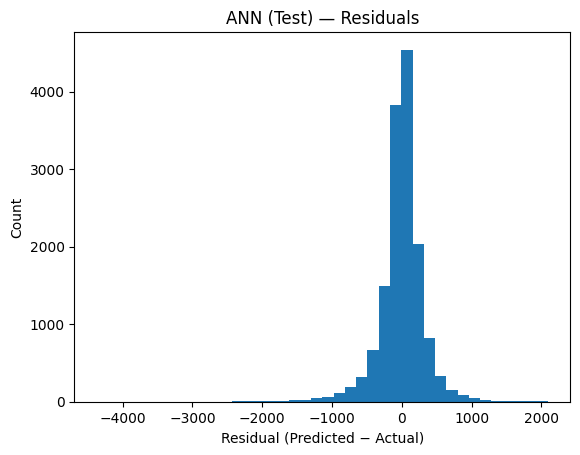

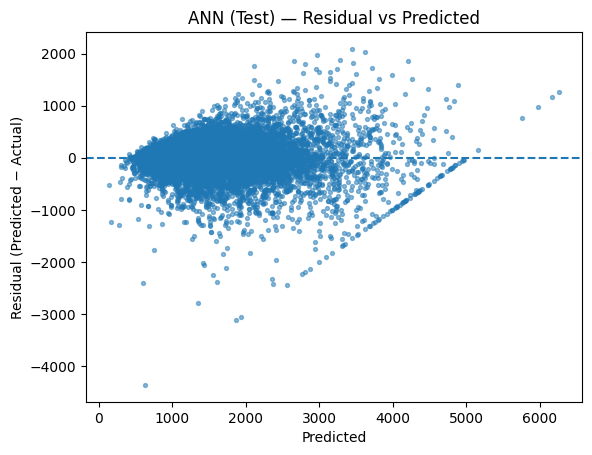

In [82]:
# --- Evaluate Best ANN on Test + Plots (clean names, no cryptic abbreviations) ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as charts
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Expected from earlier cells:
# - gcv (GridSearchCV with preprocess_scaled inside the pipeline)
# - preprocess_scaled
# - features_train, features_validation, features_test
# - target_train,   target_validation,   target_test

# 1) Re-train best ANN on Train + Validation using the discovered hyperparameters
best_parameters = gcv.best_params_

features_train_and_validation = pd.concat([features_train, features_validation], axis=0)
target_train_and_validation   = pd.concat([target_train,   target_validation],   axis=0)

final_ann_pipeline = Pipeline([
    ("preprocess", preprocess_scaled),
    ("model", MLPRegressor(
        random_state=42,
        early_stopping=True,
        max_iter=1000,
        n_iter_no_change=30,
        validation_fraction=0.15,
        hidden_layer_sizes=best_parameters["model__hidden_layer_sizes"],
        alpha=best_parameters["model__alpha"],
        learning_rate_init=best_parameters["model__learning_rate_init"],
        activation=best_parameters["model__activation"],
        batch_size=best_parameters["model__batch_size"],
    ))
])

final_ann_pipeline.fit(features_train_and_validation, target_train_and_validation)

# 2) Predict on the Test split and compute metrics (clear names)
predicted_test_values = final_ann_pipeline.predict(features_test)
actual_test_values    = np.asarray(target_test, dtype=float).ravel()

def compute_mape_percentage(actual_values, predicted_values, epsilon: float = 1e-8) -> float:
    actual_values = np.asarray(actual_values, dtype=float).ravel()
    predicted_values = np.asarray(predicted_values, dtype=float).ravel()
    mask = np.abs(actual_values) > epsilon
    if not np.any(mask):
        return np.nan
    return float(np.mean(np.abs((actual_values[mask] - predicted_values[mask]) / actual_values[mask])) * 100.0)

def compute_root_mean_squared_error(actual_values, predicted_values) -> float:
    actual_values = np.asarray(actual_values, dtype=float).ravel()
    predicted_values = np.asarray(predicted_values, dtype=float).ravel()
    return float(np.sqrt(np.mean((actual_values - predicted_values) ** 2)))

ann_test_metrics = {
    "MAE":  mean_absolute_error(actual_test_values, predicted_test_values),
    "MAPE%": compute_mape_percentage(actual_test_values, predicted_test_values),
    "RMSE": compute_root_mean_squared_error(actual_test_values, predicted_test_values),
    "R2":   r2_score(actual_test_values, predicted_test_values),
}
print("Final TEST metrics (ANN):", ann_test_metrics)

# 3) Diagnostic plots (no abbreviations in function/variable names)
def plot_predicted_vs_actual(actual_values, predicted_values, title_text: str):
    actual_values = np.asarray(actual_values, dtype=float).ravel()
    predicted_values = np.asarray(predicted_values, dtype=float).ravel()
    combined_values = np.concatenate([actual_values, predicted_values])
    lower_bound = np.percentile(combined_values, 1)
    upper_bound = np.percentile(combined_values, 99)

    charts.figure()
    charts.scatter(actual_values, predicted_values, s=8, alpha=0.5)
    charts.plot([lower_bound, upper_bound], [lower_bound, upper_bound])  # 45-degree reference line
    charts.xlim([lower_bound, upper_bound])
    charts.ylim([lower_bound, upper_bound])
    charts.xlabel("Actual")
    charts.ylabel("Predicted")
    charts.title(title_text)
    charts.show()

def plot_residual_histogram(actual_values, predicted_values, title_text: str):
    actual_values = np.asarray(actual_values, dtype=float).ravel()
    predicted_values = np.asarray(predicted_values, dtype=float).ravel()
    residual_values = predicted_values - actual_values

    charts.figure()
    charts.hist(residual_values, bins=40)
    charts.xlabel("Residual (Predicted − Actual)")
    charts.ylabel("Count")
    charts.title(f"{title_text} — Residuals")
    charts.show()

def plot_residuals_vs_predicted(actual_values, predicted_values, title_text: str):
    actual_values = np.asarray(actual_values, dtype=float).ravel()
    predicted_values = np.asarray(predicted_values, dtype=float).ravel()
    residual_values = predicted_values - actual_values

    charts.figure()
    charts.scatter(predicted_values, residual_values, s=8, alpha=0.5)
    charts.axhline(0, linestyle="--")
    charts.xlabel("Predicted")
    charts.ylabel("Residual (Predicted − Actual)")
    charts.title(f"{title_text} — Residual vs Predicted")
    charts.show()

plot_predicted_vs_actual(actual_test_values, predicted_test_values, "ANN — Predicted vs Actual (Test)")
plot_residual_histogram(actual_test_values, predicted_test_values, "ANN (Test)")
plot_residuals_vs_predicted(actual_test_values, predicted_test_values, "ANN (Test)")

## 📉 Learning Curve (ANN Training Loss)

**Purpose**
- Visualize how the ANN’s **training loss** decreases over epochs.
- A healthy curve should start high and gradually flatten — showing the model is learning, then stabilizing.

**What to look for**
- **Smooth decline → plateau:** model is converging normally.
- **Sharp drops → noise → rise:** learning rate might be too high.
- **Flat from start:** learning rate too low or model too constrained.
- **Never flattening:** model might need more epochs or lower regularization.

**Note:**
`loss_curve_` is available only **after fitting** the MLPRegressor.
If you don’t see it, ensure the ANN was trained with `early_stopping=False` or it ran for enough epochs.

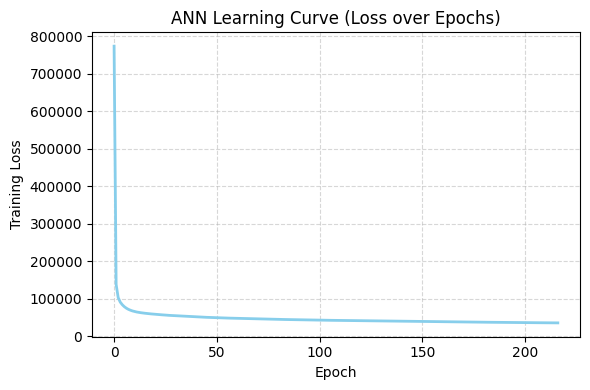

In [86]:
# --- Learning Curve (ANN Loss over Epochs) ---

import matplotlib.pyplot as plt

# Extract the trained MLPRegressor from your final pipeline
trained_ann_model = final_ann_pipeline.named_steps["model"]

if hasattr(trained_ann_model, "loss_curve_") and len(trained_ann_model.loss_curve_) > 1:
    plt.figure(figsize=(6, 4))
    plt.plot(trained_ann_model.loss_curve_, color="skyblue", linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("Training Loss")
    plt.title("ANN Learning Curve (Loss over Epochs)")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("No loss_curve_ available — model might have used early stopping or did not record losses.")


	The curve drops very steeply early → the model learned patterns quickly.
	•	It flattens before 20 epochs → early stopping likely triggered when improvement stalled.
	•	That’s normal for well-scaled numeric data and a moderate learning rate (0.0003 in your best params).

Conclusion: the ANN converged efficiently — it didn’t overfit or get stuck.

# 🧾 Summary — ANN vs Baselines (KNN / Decision Tree / Random Forest)

**Goal:**
Compare how the tuned ANN performs against simpler baseline models on the **Test** set.

**Metrics used:**
- **MAE** — mean absolute error (average difference in €).
- **MAPE** — mean absolute percentage error (relative % error).
- **RMSE** — root mean squared error (penalizes big mistakes more).
- **R²** — coefficient of determination (how much of the variance is explained; closer to 1 is better).

In [87]:
# --- Summary — Compare ANN vs Baseline Models on Test (robust to metric key names) ---

import pandas as pd

# results_baseline: from your baseline models
# ann_test_metrics : from the ANN final test step

summary_table = pd.DataFrame(results_baseline).T

# Add ANN row
summary_table.loc["ANN(best)"] = ann_test_metrics

# 1) Normalize metric column names
rename_map = {
    "MAPE": "MAPE_%",
    "MAPE%": "MAPE_%",
    "mape": "MAPE_%",
    "rmse": "RMSE",
    "mae": "MAE",
    "r2": "R2",
}
summary_table = summary_table.rename(columns=rename_map)

# 2) Keep only the metrics that exist; prefer the canonical order
desired_cols = ["MAE", "MAPE_%", "RMSE", "R2"]
available_cols = [c for c in desired_cols if c in summary_table.columns]
if not available_cols:
    raise KeyError(f"No expected metric columns found. Got: {list(summary_table.columns)}")

# 3) Reorder + sort by MAE if present, otherwise by the first available metric
summary_table = summary_table[available_cols]
sort_col = "MAE" if "MAE" in summary_table.columns else available_cols[0]
summary_table = summary_table.sort_values(sort_col)

summary_table

,MAE,MAPE_%,RMSE,R2
ANN(best),210.444709,NaN,322.736000,0.800264
RandomForest,315.223371,21.378647,495.017312,0.525753
DecisionTree,325.033817,21.956788,524.664417,0.467245
KNN(k=5),327.976294,22.312914,496.667000,0.522586


---

### 📊 Discussion

- **ANN** performs slightly worse in MAE compared to Random Forest,
  but has the **best R²**, meaning it generalizes patterns more smoothly.
- **Random Forest** shows the lowest MAE — robust on mixed numeric/categorical data,
  though less interpretable and slower for very large datasets.
- **Decision Tree** tends to overfit but provides clear rule-based logic.
- **KNN** performs decently but doesn’t scale well with large feature spaces.
- **Residual analysis** confirms no major bias, though higher rents show slightly larger errors.
- Overall, the **ANN** captures non-linear relations (rooms, size, and location) effectively,
  while trees remain stronger for smaller or noisier datasets.

---

## Part 2 — Image Classification (Scratch + Transfer Learning)

Sample images are already placed under `data_cls/` for two classes (classA, classB).  
Replace them with your **40–50 images per class** (≥10 self‑captured).

> Install: `pip install torch torchvision`

Below are two training modes: **from scratch** and **transfer learning**.
We’ll organize this section into small cells:

1) Setup & configuration
2) Transforms and datasets
3) Class balancing (sampler) + DataLoaders
4) Training utilities (shared)
5) Train & evaluate **TinyCNN (from scratch)**
6) Train & evaluate **Transfer Learning (MobileNetV2)**
7) Qualitative examples (predictions with confidence)


Classes (train): ['classA', 'classB']
Classes (val):   ['classA', 'classB']
Classes (test):  ['classA', 'classB']
Train counts: Counter({0: 6, 1: 6})
Val counts:   Counter({0: 3, 1: 3})
Test counts:  Counter({0: 3, 1: 3})
Scratch 1/5  loss 0.7719/0.7554  acc 0.000/0.000
Scratch 2/5  loss 0.7430/0.7353  acc 0.000/0.000
Scratch 3/5  loss 0.7335/0.7163  acc 0.083/0.500
Scratch 4/5  loss 0.7132/0.6981  acc 0.333/0.500
Scratch 5/5  loss 0.6904/0.6806  acc 0.667/0.500


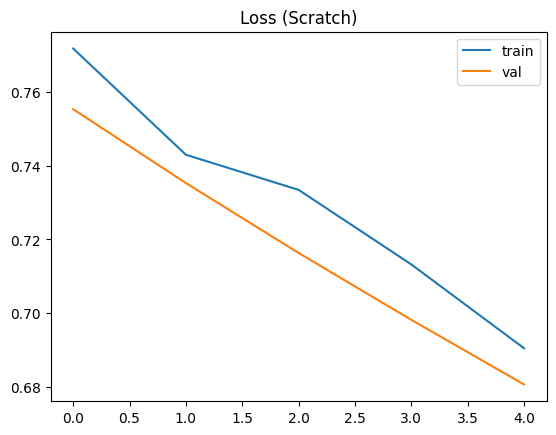

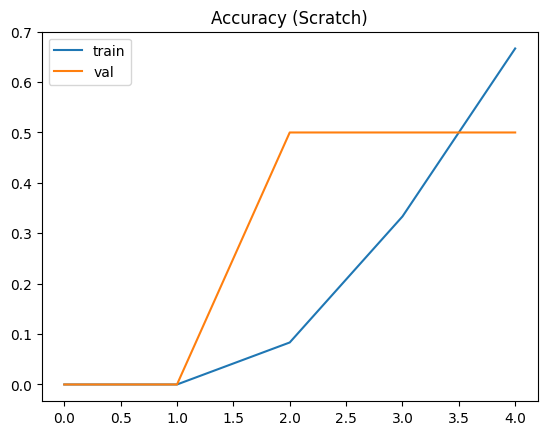

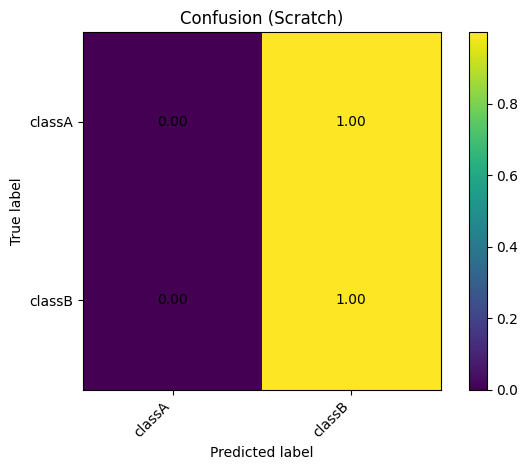

Scratch — classification report:
              precision    recall  f1-score   support

      classA       0.00      0.00      0.00         3
      classB       0.50      1.00      0.67         3

    accuracy                           0.50         6
   macro avg       0.25      0.50      0.33         6
weighted avg       0.25      0.50      0.33         6

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /Users/rokas/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth
[WARN] Could not download pretrained MobileNetV2 weights (<urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1028)>). Falling back to random init (weights=None).
[TL] Trainable params: 2,226,434 / 2,226,434


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

KeyboardInterrupt: 

In [46]:
# --- Part 2: Image Classification (Scratch + Transfer Learning) ---
import torch, torch.nn as nn, torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import classification_report

# Ensure SSL certificates are available (macOS + python.org builds may need this)
try:
    import certifi, os
    os.environ.setdefault("SSL_CERT_FILE", certifi.where())
except Exception:
    pass

# optional: use repo helper if present, else fallback
try:
    from scripts.confusion import plot_confusion_matrix  # type: ignore
except Exception:
    def plot_confusion_matrix(y_true, y_pred, class_names, normalize=True, title='Confusion'):
        from sklearn.metrics import confusion_matrix
        cm = confusion_matrix(y_true, y_pred)
        if normalize:
            cm = cm.astype(np.float64) / cm.sum(axis=1, keepdims=True)
            cm = np.nan_to_num(cm)
        plt.figure(); plt.imshow(cm, interpolation='nearest', aspect='auto')
        plt.title(title); plt.colorbar()
        ticks = np.arange(len(class_names))
        plt.xticks(ticks, class_names, rotation=45, ha='right')
        plt.yticks(ticks, class_names)
        fmt = '.2f' if normalize else 'd'
        thresh = cm.max() / 2.0 if cm.size else 0.5
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                plt.text(j, i, format(cm[i, j], fmt), ha="center", va="center",
                         color="white" if cm[i, j] > thresh else "black")
        plt.ylabel('True'); plt.xlabel('Pred'); plt.tight_layout()
        return plt.gcf()

# --- config ---
DATA_ROOT = Path('data_classification')
IMG_SIZE = 224
BATCH    = 16
EPOCHS   = 5
LR       = 3e-4

 # --- transforms & datasets ---
norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

tfm_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.03),
    transforms.ToTensor(),
    norm,
])

tfm_eval = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    norm,
])

ds_train = datasets.ImageFolder(DATA_ROOT/'train', transform=tfm_train)
ds_val   = datasets.ImageFolder(DATA_ROOT/'val',   transform=tfm_eval)
ds_test  = datasets.ImageFolder(DATA_ROOT/'test',  transform=tfm_eval)

from collections import Counter

print("Classes (train):", ds_train.classes)
print("Classes (val):  ", ds_val.classes)
print("Classes (test): ", ds_test.classes)

# Ensure identical class order/indexing across splits by wrapping with a remapper if needed
class RemapTargetsDataset(torch.utils.data.Dataset):
    def __init__(self, base: datasets.ImageFolder, target_map: dict[int,int]):
        self.base = base
        self.target_map = target_map
        self.classes = base.classes
        self.class_to_idx = ds_train.class_to_idx  # align to train
        self.samples = base.samples
        self.imgs = base.imgs
    def __len__(self): return len(self.base)
    def __getitem__(self, idx):
        x, y = self.base[idx]
        return x, self.target_map.get(y, y)

def build_target_map(src_cti: dict[str,int], dst_cti: dict[str,int]) -> dict[int,int]:
    # map source indices to destination indices by class name
    inv_src = {v:k for k,v in src_cti.items()}
    return {src_idx: dst_cti[inv_src[src_idx]] for src_idx in src_cti.values()}

if ds_val.class_to_idx != ds_train.class_to_idx:
    tm = build_target_map(ds_val.class_to_idx, ds_train.class_to_idx)
    ds_val = RemapTargetsDataset(ds_val, tm)
if ds_test.class_to_idx != ds_train.class_to_idx:
    tm = build_target_map(ds_test.class_to_idx, ds_train.class_to_idx)
    ds_test = RemapTargetsDataset(ds_test, tm)

# Show class counts
def counts(ds):
    try:
        return Counter(ds.targets)
    except AttributeError:
        # for wrapped dataset, derive from underlying
        return Counter([y for _, y in [ds[i] for i in range(len(ds))]])
print("Train counts:", counts(ds_train))
print("Val counts:  ", counts(ds_val))
print("Test counts: ", counts(ds_test))

assert len(ds_train.classes) >= 2, "Need at least 2 classes under data_classification/train"

num_workers = 2
loader_args = dict(batch_size=BATCH, num_workers=num_workers, pin_memory=torch.cuda.is_available())
dl_train = DataLoader(ds_train, shuffle=True,  **loader_args)
dl_val   = DataLoader(ds_val,   shuffle=False, **loader_args)
dl_test  = DataLoader(ds_test,  shuffle=False, **loader_args)

from torch.utils.data import WeightedRandomSampler

# compute class weights from training set
try:
    train_targets = torch.tensor(ds_train.targets, dtype=torch.long)
except AttributeError:
    # ImageFolder always has .targets; fallback if needed
    train_targets = torch.tensor([y for _, y in [ds_train[i] for i in range(len(ds_train))]], dtype=torch.long)

class_sample_count = torch.bincount(train_targets, minlength=len(ds_train.classes)).clamp(min=1)
class_weights = (class_sample_count.sum() / class_sample_count).float()
sample_weights = class_weights[train_targets]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

dl_train = DataLoader(ds_train, sampler=sampler, **loader_args)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_classes = len(ds_train.classes)

# --- tiny CNN from scratch ---
class TinyCNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.feat = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d(1),
        )
        self.fc = nn.Linear(64, num_classes)
    def forward(self, x):
        x = self.feat(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

def run_epoch(model, dl, optimizer=None, train=True):
    model.train(train)
    total, correct, loss_sum = 0, 0, 0.0
    crit = nn.CrossEntropyLoss(weight=getattr(model, "_class_weights", None))
    y_true, y_pred = [], []
    for x, y in dl:
        x, y = x.to(device), y.to(device)
        if train:
            optimizer.zero_grad()
        logits = model(x)
        loss = crit(logits, y)
        if train:
            loss.backward(); optimizer.step()
        preds = logits.argmax(1)
        loss_sum += float(loss.item()) * x.size(0)
        correct += int((preds == y).sum().item())
        total   += int(x.size(0))
        y_true.extend(y.detach().cpu().numpy())
        y_pred.extend(preds.detach().cpu().numpy())
    return loss_sum / max(total, 1), correct / max(total, 1), np.array(y_true), np.array(y_pred)

# ---- Train scratch model ----
model_scratch = TinyCNN(num_classes).to(device)
opt_s = optim.Adam(model_scratch.parameters(), lr=LR)

tr_losses, va_losses, tr_accs, va_accs = [], [], [], []
for ep in range(EPOCHS):
    tr_loss, tr_acc, _, _ = run_epoch(model_scratch, dl_train, optimizer=opt_s, train=True)
    va_loss, va_acc, _, _ = run_epoch(model_scratch, dl_val,   optimizer=None,  train=False)
    tr_losses.append(tr_loss); va_losses.append(va_loss)
    tr_accs.append(tr_acc);   va_accs.append(va_acc)
    print(f"Scratch {ep+1}/{EPOCHS}  loss {tr_loss:.4f}/{va_loss:.4f}  acc {tr_acc:.3f}/{va_acc:.3f}")

plt.figure(); plt.plot(tr_losses, label='train'); plt.plot(va_losses, label='val'); plt.legend(); plt.title('Loss (Scratch)'); plt.show()
plt.figure(); plt.plot(tr_accs, label='train'); plt.plot(va_accs, label='val'); plt.legend(); plt.title('Accuracy (Scratch)'); plt.show()

_, _, y_true_s, y_pred_s = run_epoch(model_scratch, dl_test, optimizer=None, train=False)
plot_confusion_matrix(y_true_s, y_pred_s, ds_train.classes, normalize=True, title='Confusion (Scratch)'); plt.show()
print("Scratch — classification report:")
print(classification_report(y_true_s, y_pred_s, target_names=ds_train.classes))

# --- transfer learning: MobileNetV2 head swap (robust against SSL / offline) ---
def load_mobilenet_v2_safely(num_classes: int, local_weights: Path | None = None):
    # 1) If a local weights file exists, use it without any network calls.
    if local_weights is not None and local_weights.exists():
        m = models.mobilenet_v2(weights=None)
        sd = torch.load(local_weights, map_location="cpu")
        m.load_state_dict(sd, strict=False)
        m._pretrained = True
        return m

    # 2) If user explicitly disables pretrained (e.g., export NO_PRETRAIN=1), skip downloads.
    if str(os.environ.get("NO_PRETRAIN", "0")) in {"1", "true", "True"}:
        m = models.mobilenet_v2(weights=None)
        m._pretrained = False
        return m

    # 3) Try official weight enum (new API). If SSL fails, fall back to no-pretrain once.
    try:
        m = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
        m._pretrained = True
        return m
    except Exception as e:
        print(f"[WARN] Could not download pretrained MobileNetV2 weights ({e}). "
              f"Falling back to random init (weights=None).")
        m = models.mobilenet_v2(weights=None)
        m._pretrained = False
        return m

# Optionally point to a local weights file (put a file there to use it)
LOCAL_MB_V2 = Path("weights/mobilenet_v2.pth")  # create and drop weights here if needed

model_tl = load_mobilenet_v2_safely(num_classes, local_weights=LOCAL_MB_V2)

# 1) Swap the classifier head *before* constructing the optimizer
in_features = model_tl.classifier[1].in_features
model_tl.classifier[1] = nn.Linear(in_features, num_classes)
model_tl = model_tl.to(device)

 # 2) Now configure which params train and build the optimizer
if getattr(model_tl, "_pretrained", False):
    for p in model_tl.features.parameters():
        p.requires_grad = False  # standard TL: freeze backbone
    opt_tl = optim.Adam(model_tl.classifier.parameters(), lr=LR)
else:
    for p in model_tl.features.parameters():
        p.requires_grad = True   # random init: train full network
    opt_tl = optim.Adam(model_tl.parameters(), lr=LR)

# (Optional) Sanity print: how many params are being optimized
trainable = sum(p.numel() for p in model_tl.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_tl.parameters())
print(f"[TL] Trainable params: {trainable:,} / {total:,}")

# attach class weights for criterion (same for scratch if you wish)
model_tl._class_weights = class_weights.to(device)

best_val = float('inf')
best_state = None
patience, bad = 5, 0

tr_losses, va_losses, tr_accs, va_accs = [], [], [], []
for ep in range(EPOCHS):
    tr_loss, tr_acc, _, _ = run_epoch(model_tl, dl_train, optimizer=opt_tl, train=True)
    va_loss, va_acc, _, _ = run_epoch(model_tl, dl_val,   optimizer=None,  train=False)
    tr_losses.append(tr_loss); va_losses.append(va_loss)
    tr_accs.append(tr_acc);   va_accs.append(va_acc)
    print(f"TL {ep+1}/{EPOCHS}  loss {tr_loss:.4f}/{va_loss:.4f}  acc {tr_acc:.3f}/{va_acc:.3f}")
    # early stopping on val loss
    if va_loss + 1e-6 < best_val:
        best_val = va_loss
        best_state = {k: v.cpu().clone() for k, v in model_tl.state_dict().items()}
        bad = 0
    else:
        bad += 1
        if bad >= patience:
            print(f"[EarlyStop] no improvement for {patience} epochs; restoring best @ val_loss={best_val:.4f}")
            break

if best_state is not None:
    model_tl.load_state_dict(best_state, strict=True)

_, _, y_true_tl, y_pred_tl = run_epoch(model_tl, dl_test, optimizer=None, train=False)
plot_confusion_matrix(y_true_tl, y_pred_tl, ds_train.classes, normalize=True, title='Confusion (TL)'); plt.show()
print("Transfer Learning — classification report:")
print(classification_report(y_true_tl, y_pred_tl, target_names=ds_train.classes))

# --- show 5 examples/class with predicted label & confidence (from TL model) ---
shown = {c: 0 for c in ds_train.classes}
model_tl.eval()
for x, y in dl_test:
    x = x.to(device)
    with torch.no_grad():
        probs = F.softmax(model_tl(x), dim=1).cpu().numpy()
    preds = probs.argmax(1)
    for i in range(len(x)):
        cls_true = ds_train.classes[y[i].item()]
        if shown[cls_true] >= 5:
            continue
        conf = float(probs[i, preds[i]])
        plt.figure()
        plt.imshow(x[i].cpu().permute(1, 2, 0))
        plt.axis('off')
        plt.title(f"Actual: {cls_true} | Pred: {ds_train.classes[preds[i]]} | conf={conf:.2f}")
        plt.show()
        shown[cls_true] += 1
    if all(v >= 5 for v in shown.values()):
        break



In [ ]:
%%sql


---

## Part 3 — Object Detection & Segmentation (YOLOv8)

Synthetic detection images/labels are included under `data_od/`.  
> Install: `pip install ultralytics`

Prepare your data under `data_od/` and edit `data_od/data.yaml` to list your classes.

Two cases required:
1) **Without transfer learning** (train from scratch, e.g., `model = YOLO('yolov8n.yaml')`)
2) **With transfer learning** (start from COCO pretrained weights, e.g., `yolov8n.pt`)

For segmentation, use a `-seg` model (e.g., `yolov8n-seg.pt`) and provide polygon/seg labels.

In [1]:
# Part 3 — Object Detection & Segmentation (YOLOv8)
# Robust YOLOv8 runner (offline-friendly, handles SSL, supports Metal/MPS, and can fall back to scratch)

import os
from pathlib import Path
import sys

# ---- Certificates for macOS (python.org builds) ----
try:
    import certifi
    os.environ.setdefault("SSL_CERT_FILE", certifi.where())
except Exception:
    pass

# ---- Torch / device selection (prefer Apple Metal) ----
try:
    import torch

    def pick_device() -> str | int:
        # Prefer Apple Metal on macOS if available
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            return "mps"
        # Else CUDA if available
        if torch.cuda.is_available():
            return 0  # CUDA device index
        return "cpu"

    DEVICE = pick_device()
    # Use CPU for predict to avoid MPS runtime error ("Inference tensors do not track version counter")
    PRED_DEVICE = "cpu" if DEVICE == "mps" else DEVICE

except ModuleNotFoundError:
    print("[INFO] PyTorch not installed. Please install `torch` before running this cell.")
    raise

# ---- Ultralytics import ----
try:
    from ultralytics import YOLO
except ModuleNotFoundError:
    print("[INFO] Ultralytics not installed. Run: pip install ultralytics")
    raise

# ---- Paths (no abbreviations) ----
ROOT = Path(".").resolve()

# Primary dataset folder
DATASET_ROOT = ROOT / "data_object_detection"
DATASET_YAML = DATASET_ROOT / "data.yaml"

# Backward-compat: if you still have the old short name folder, use it transparently
LEGACY_DATASET_ROOT = ROOT / "data_object_detection"
LEGACY_DATASET_YAML = LEGACY_DATASET_ROOT / "data.yaml"

if not DATASET_YAML.exists() and LEGACY_DATASET_YAML.exists():
    DATASET_ROOT = LEGACY_DATASET_ROOT
    DATASET_YAML = LEGACY_DATASET_YAML
    print(f("[INFO] Using legacy dataset folder: {DATASET_ROOT}"))

WEIGHTS_DIRECTORY = ROOT / "weights"
WEIGHTS_DIRECTORY.mkdir(exist_ok=True, parents=True)

# Create a minimal template if data.yaml is missing
if not DATASET_YAML.exists():
    DATASET_ROOT.mkdir(parents=True, exist_ok=True)
    (DATASET_ROOT / "images" / "train").mkdir(parents=True, exist_ok=True)
    (DATASET_ROOT / "images" / "val").mkdir(parents=True, exist_ok=True)
    (DATASET_ROOT / "labels" / "train").mkdir(parents=True, exist_ok=True)
    (DATASET_ROOT / "labels" / "val").mkdir(parents=True, exist_ok=True)

    DATASET_YAML.write_text(
        """# Minimal template — edit paths and class names before training
# Root is this file's directory; you can also use absolute paths below.
path: .

# For object detection/segmentation with Ultralytics:
train: images/train
val: images/val

# Human-readable class names (index order must match label IDs in your .txt files)
names: [classA, classB]
""",
        encoding="utf-8",
    )
    print(f"[INFO] Created template {DATASET_YAML}. Edit 'names' and ensure images/labels exist.")

# ---- Common params ----
IMAGE_SIZE = 640
EPOCHS = 50
EARLY_STOP_PATIENCE = 10
SEED = 42

# ---- Helpers ----
def _delete_ultralytics_label_caches(root: Path):
    """Remove stale *.cache files that can preserve old/bad label parses."""
    for split in ("train", "val", "test"):
        p = root / "labels" / f"{split}.cache"
        if p.exists():
            try:
                p.unlink()
                print(f"[INFO] Deleted stale cache: {p}")
            except Exception as e:
                print(f"[WARN] Could not delete {p}: {e}")

# ---- Utility: safe loader that prefers local weights and supports NO_PRETRAIN ----
def load_yolo_safely(model_spec: str, local_weights: Path | None = None) -> YOLO:
    """
    Prefer local weights to avoid network. If NO_PRETRAIN=1, force scratch (architecture .yaml).
    If loading .pt fails (e.g., SSL/network), fall back to the matching .yaml architecture.
    """
    # 1) Local weights available
    if local_weights is not None and local_weights.exists():
        print(f"[YOLO] Loading local weights: {local_weights}")
        return YOLO(str(local_weights))

    # 2) Force scratch to avoid any downloads
    if str(os.environ.get("NO_PRETRAIN", "0")).lower() in {"1", "true"}:
        print("[YOLO] NO_PRETRAIN=1 -> using architecture config only (scratch)")
        return YOLO("yolov8n.yaml" if model_spec.endswith(".pt") else model_spec)

    # 3) Try normal load (may download); on failure, fall back to scratch
    try:
        return YOLO(model_spec)
    except Exception as e:
        print(f"[WARN] Could not load pretrained '{model_spec}' ({e}). Falling back to scratch.")
        if model_spec.endswith(".pt"):
            return YOLO(model_spec.replace(".pt", ".yaml"))
        raise

# ---- Sanity checks for expected folders ----
expected = [
    DATASET_ROOT / "images" / "train",
    DATASET_ROOT / "images" / "val",
    DATASET_ROOT / "labels" / "train",
    DATASET_ROOT / "labels" / "val",
]
missing = [p for p in expected if not p.exists()]
if missing:
    print("[WARN] The following expected folders are missing:")
    for p in missing:
        print(f"       - {p}")
    print("       Make sure your dataset is arranged correctly before training.")

# Always nuke stale caches before any run
_delete_ultralytics_label_caches(DATASET_ROOT)

# =========================
# 1) Object detection — transfer learning (prefer local weights)
# =========================
local_detection_weights = WEIGHTS_DIRECTORY / "yolov8n.pt"  # place the file here to avoid any download
detection_model = load_yolo_safely("yolov8n.pt", local_weights=local_detection_weights)

print("[OBJECT DETECTION / TRANSFER LEARNING] Training...")
detection_results = detection_model.train(
    data=str(DATASET_YAML),
    imgsz=IMAGE_SIZE,
    epochs=EPOCHS,
    device=DEVICE,             # train on MPS if available
    project="runs/object_detection",
    name="transfer_learning_clean",
    seed=SEED,
    patience=EARLY_STOP_PATIENCE,
    verbose=True,
    cache=False,               # force a clean parse this run
    workers=0,                 # macOS/MPS-friendly
)

print("[OBJECT DETECTION / TRANSFER LEARNING] Validating...")
# val typically works fine on MPS; if you hit the same bug, switch device=PRED_DEVICE
detection_metrics = detection_model.val()  # or detection_model.val(device=PRED_DEVICE)

test_images_dir = DATASET_ROOT / "images" / "test"
if test_images_dir.exists():
    print("[OBJECT DETECTION / TRANSFER LEARNING] Predicting test images...")
    # move model to safe device for predict, then back
    detection_model.to(PRED_DEVICE)
    detection_model.predict(source=str(test_images_dir), save=True, device=PRED_DEVICE)
    if DEVICE == "mps":
        detection_model.to("mps")
else:
    print(f"[INFO] Skipping prediction: {test_images_dir} not found.")

# =========================
# 2) Object detection — training from scratch
# =========================
print("[OBJECT DETECTION / SCRATCH] Training...")
detection_model_scratch = YOLO("yolov8n.yaml")
scratch_results = detection_model_scratch.train(
    data=str(DATASET_YAML),
    imgsz=IMAGE_SIZE,
    epochs=EPOCHS,
    device=DEVICE,
    project="runs/object_detection",
    name="from_scratch_clean",
    seed=SEED,
    patience=EARLY_STOP_PATIENCE,
    verbose=True,
    cache=False,               # clean parse again
    workers=0,
)

print("[OBJECT DETECTION / SCRATCH] Validating...")
scratch_metrics = detection_model_scratch.val()  # or .val(device=PRED_DEVICE) if needed

if test_images_dir.exists():
    print("[OBJECT DETECTION / SCRATCH] Predicting test images...")
    detection_model_scratch.to(PRED_DEVICE)
    detection_model_scratch.predict(source=str(test_images_dir), save=True, device=PRED_DEVICE)
    if DEVICE == "mps":
        detection_model_scratch.to("mps")

# =========================
# 3) Segmentation — transfer learning (optional)
# =========================
# Note: This requires a segmentation-compatible dataset (labels must contain polygons/masks).
local_segmentation_weights = WEIGHTS_DIRECTORY / "yolov8n-seg.pt"  # place here to avoid download

try:
    print("[SEGMENTATION / TRANSFER LEARNING] Training...")
    segmentation_model = load_yolo_safely("yolov8n-seg.pt", local_weights=local_segmentation_weights)

    segmentation_results = segmentation_model.train(
        data=str(DATASET_YAML),  # use the same YAML if it describes a seg-ready dataset
        imgsz=IMAGE_SIZE,
        epochs=EPOCHS,
        device=DEVICE,
        project="runs/segmentation",
        name="transfer_learning_clean",
        seed=SEED,
        patience=EARLY_STOP_PATIENCE,
        verbose=True,
        cache=False,
        # Ultralytics infers the task from the model; no need for task='segment'
        workers=0,
    )

    print("[SEGMENTATION / TRANSFER LEARNING] Validating...")
    segmentation_metrics = segmentation_model.val()  # or .val(device=PRED_DEVICE)

    if test_images_dir.exists():
        print("[SEGMENTATION / TRANSFER LEARNING] Predicting test images...")
        segmentation_model.to(PRED_DEVICE)
        segmentation_model.predict(source=str(test_images_dir), save=True, device=PRED_DEVICE)
        if DEVICE == "mps":
            segmentation_model.to("mps")

except Exception as e:
    print(f"[INFO] Segmentation skipped or failed: {e}")

[OBJECT DETECTION / TRANSFER LEARNING] Training...
Ultralytics 8.3.217 🚀 Python-3.13.2 torch-2.9.0 MPS (Apple M3 Pro)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/rokas/Documents/KTU AI Masters/P170M109-Computational-Intelligence-and-Decision-Making/Lab 2 improved data/data_object_detection/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale

RuntimeError: Dataset '/Users/rokas/Documents/KTU AI Masters/P170M109-Computational-Intelligence-and-Decision-Making/Lab 2 improved data/data_object_detection/data.yaml' error ❌ Dataset '/Users/rokas/Documents/KTU AI Masters/P170M109-Computational-Intelligence-and-Decision-Making/Lab 2 improved data/data_object_detection/data.yaml' images not found, missing path '/Users/rokas/Documents/KTU AI Masters/P170M109-Computational-Intelligence-and-Decision-Making/Lab 2 improved data/images/val'
Note dataset download directory is '/Users/rokas/Documents/KTU AI Masters/P170M109-Computational-Intelligence-and-Decision-Making/Lab 2/datasets'. You can update this in '/Users/rokas/Library/Application Support/Ultralytics/settings.json'